In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from scipy import stats
from scipy.stats import rankdata
import pickle
import mne
import os
current_path = os.getcwd()

In [2]:
blue_color = plt.cm.Blues(0.6)

In [3]:
import pickle

file_path = '../data/hdEEG/sub1/sub-01_run-07_100_100_metrics.pkl'

# Open the file in 'rb' mode (read binary)
with open(file_path, 'rb') as file:
    data_1 = pickle.load(file)

In [4]:
Entrainment_pre=list(data_1['metrics_pre']['salience'].values())

In [5]:
Entrainment_post=list(data_1['metrics_post']['salience'].values())

# Q1 vs rand trials (hdEEG)

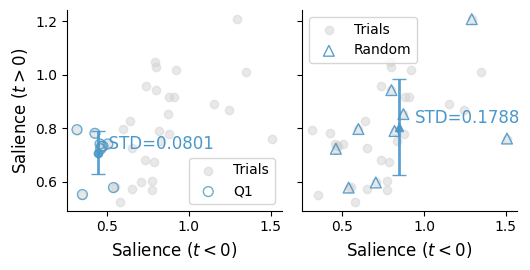

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pre_vals = np.asarray(Entrainment_pre)
post_vals = np.asarray(Entrainment_post)


# Define Q1 and Random subsets
q1_thr = np.quantile(pre_vals, 0.25)
q1_idx = np.where(pre_vals <= q1_thr)[0]
rand_idx = np.random.choice(len(pre_vals), size=len(q1_idx), replace=False)

# Compute spreads
std_q1 = np.std(post_vals[q1_idx])
mean_q1 = np.mean(post_vals[q1_idx])
std_rand = np.std(post_vals[rand_idx])
mean_rand = np.mean(post_vals[rand_idx])

# Set global style
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.8), sharey=True)

## --- Left: Q1 subset ---
axes[0].scatter(pre_vals, post_vals, color="lightgray", alpha=0.5, label='Trials')
axes[0].scatter(pre_vals[q1_idx], post_vals[q1_idx],
                facecolor="none", alpha=0.8, edgecolor=blue_color, s=50, label='Q1')
# Spread as vertical error bar
axes[0].errorbar(x=np.mean(pre_vals[q1_idx]), y=mean_q1,
                 yerr=std_q1, fmt="o", color=blue_color,
                 capsize=5, lw=2, alpha=0.9)
axes[0].text(np.mean(pre_vals[q1_idx]), mean_q1, f"  STD={std_q1:.4f}",
             fontsize=12, color=blue_color, va="bottom")
axes[0].legend()

## --- Right: Random subset ---
axes[1].scatter(pre_vals, post_vals, color="lightgray", alpha=0.5, label='Trials')
axes[1].scatter(pre_vals[rand_idx], post_vals[rand_idx],
                facecolor="none", edgecolor=blue_color, alpha=0.9, marker="^", s=60, label='Random')
# Spread as vertical error bar
axes[1].errorbar(x=np.mean(pre_vals[rand_idx]), y=mean_rand,
                 yerr=std_rand, fmt="^", color=blue_color,
                 capsize=5, lw=2, alpha=0.9)
axes[1].text(np.mean(pre_vals[rand_idx])+0.1, mean_rand, f"STD={std_rand:.4f}",
             fontsize=12, color=blue_color, va="bottom")
#axes[1].set_title("Random trials", fontsize=13)
axes[1].legend(loc='upper left')

# Shared labels
for ax in axes:
    ax.set_xlabel("Salience ($t<0$)", fontsize=12)
axes[0].set_ylabel("Salience ($t>0$)", fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/Figure_4_hdEEG_reduction_variability_salience.png', dpi=300, transparent=True)  # Transparent PNG
plt.show()

In [7]:
epoched = mne.read_epochs('../data/hdEEG/sub1/sub-01_run-01_epoched.fif', verbose=False).apply_baseline(baseline=(-0.3, -0.05));
dat_wake=np.swapaxes(np.swapaxes(epoched.get_data(),0,2),0,1)
dat_wake=dat_wake[:,:-1,:]
dat_wake.shape

Applying baseline correction (mode: mean)


/var/folders/9d/t9bsbbcj6tb1lzb02lt5xkfc0000gq/T/ipykernel_5936/3742303263.py:1: RuntimeWarning: This filename (../data/hdEEG/sub1/sub-01_run-01_epoched.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epoched = mne.read_epochs('../data/hdEEG/sub1/sub-01_run-01_epoched.fif', verbose=False).apply_baseline(baseline=(-0.3, -0.05));


(185, 1000, 36)

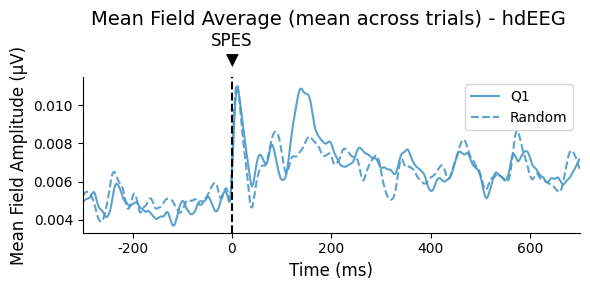

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Mean field average: std across channels for each trial, then mean across trials
# dat_wake shape: (channels, time_points, trials)
fig, ax = plt.subplots(figsize=(6, 3))

# Compute std across channels (axis=0) for Q1 and random trials
# Result shape: (time_points, num_trials)
mfa_q1 = np.mean(np.std(dat_wake[:, :, q1_idx], axis=0), axis=1)  # Mean across Q1 trials
mfa_rand = np.mean(np.std(dat_wake[:, :, rand_idx], axis=0), axis=1)  # Mean across random trials

ax.plot(1000*mfa_q1, color=blue_color, alpha=0.9, linewidth=1.5, label='Q1')
ax.plot(1000*mfa_rand, linestyle='--', color=blue_color, alpha=0.9, linewidth=1.5, label='Random')

# Labels and formatting
ax.set_xlabel("Time (ms)", fontsize=12)
ax.set_ylabel("Mean Field Amplitude (μV)", fontsize=12)
ax.set_title("Mean Field Average (mean across trials) - hdEEG \n \n", fontsize=14)
ax.grid(False)
ax.set_xticks([100,300,500,700,900])
ax.set_xticklabels([-200, 0, 200, 400, 600])
ax.set_xlim(0, 1000)
ax.axvline(300, linestyle='dashed', color='k')
ax.text(300, ax.get_ylim()[1] * 1.05, "SPES\n▼", fontsize=12, color='k', ha='center')
ax.legend()

plt.tight_layout()
#plt.savefig('../results/figures/hdEEG_reduction_mean_mfa.png', dpi=300, transparent=True)  # Transparent PNG
plt.show()

In [11]:
q1_idx

array([ 1,  2, 15, 18, 22, 27, 31, 34, 35])

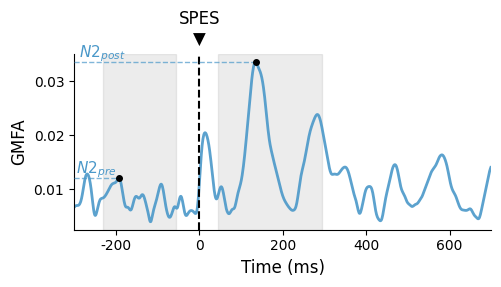

In [14]:
# Mean field average: overall average across all trials
fig, ax = plt.subplots(figsize=(5.2, 3))

# Combine all trials (Q1 and random) and compute mean field average
all_trials_idx = [15]#np.concatenate([q1_idx, rand_idx])
mfa_all = np.mean(np.std(dat_wake[:, :, all_trials_idx], axis=0), axis=1)  # Mean across all trials

ax.plot(1000*mfa_all, color=blue_color, alpha=0.9, linewidth=2)

# Add shaded regions: -230 to -55 ms and 45 to 295 ms
# Convert time in ms to index: index = time_in_ms + 300
ax.axvspan(-230 + 300, -55 + 300, alpha=0.15, color='gray')  # Pre-stimulus baseline
ax.axvspan(45 + 300, 295 + 300, alpha=0.15, color='gray')    # Pre-stimulus window

# Find maximum within negative shaded region (-230 to -55 ms)
neg_idx_min = -230 + 300  # 70
neg_idx_max = -55 + 300   # 245
neg_max_idx = neg_idx_min + np.argmax(mfa_all[int(neg_idx_min):int(neg_idx_max)])
neg_max_val = mfa_all[int(neg_max_idx)]

# Find maximum within positive shaded region (45 to 295 ms)
pos_idx_min = 45 + 300   # 345
pos_idx_max = 295 + 300  # 595
pos_max_idx = pos_idx_min + np.argmax(mfa_all[int(pos_idx_min):int(pos_idx_max)])
pos_max_val = mfa_all[int(pos_max_idx)]

# Mark N2_pre and N2_post on plot
# N2_pre: small dot with dashed line to y-axis
ax.plot(neg_max_idx, 1000*neg_max_val, 'o', color='k', markersize=4, zorder=5)
ax.plot([0, neg_max_idx], [1000*neg_max_val, 1000*neg_max_val], linestyle='--', color=blue_color, linewidth=1, alpha=0.7, zorder=4)
ax.text(neg_max_idx/2, 1000*neg_max_val + 0.001, r'$N2_{pre}$', fontsize=11, color=blue_color, ha='center', fontweight='bold')

# N2_post: small dot with dashed line to y-axis
ax.plot(pos_max_idx, 1000*pos_max_val, 'o', color='k', markersize=4, zorder=5)
ax.plot([0, pos_max_idx], [1000*pos_max_val, 1000*pos_max_val], linestyle='--', color=blue_color, linewidth=1, alpha=0.7, zorder=4)
ax.text(pos_max_idx/6.5, 1000*pos_max_val + 0.001, r'$N2_{post}$', fontsize=11, color=blue_color, ha='center', fontweight='bold')

# Labels and formatting
ax.set_xlabel("Time (ms)", fontsize=12)
ax.set_ylabel("GMFA", fontsize=12)
ax.grid(False)
ax.set_xticks([100,300,500,700,900])
ax.set_xticklabels([-200, 0, 200, 400, 600])
ax.set_xlim(0, 1000)
ax.axvline(300, linestyle='dashed', color='k')
ax.text(300, ax.get_ylim()[1] * 1.05, "SPES\n▼", fontsize=12, color='k', ha='center')

plt.tight_layout()
plt.savefig('../results/figures/hdEEG_reduction_mean_mfa_all_trials.png', dpi=300, transparent=True)
plt.show()

NameError: name 'dat_wake' is not defined

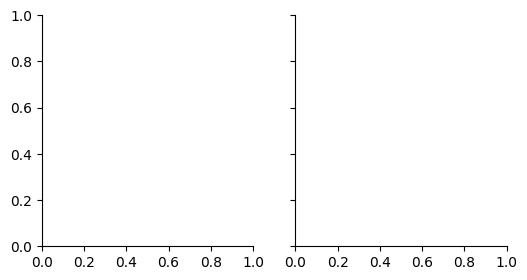

In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

# Left: Q1 trials - plot per-trial MFA
mfa_per_trial_q1 = np.std(dat_wake[:, :, q1_idx], axis=0).T  # Shape: (num_q1_trials, time_points)
for i in range(mfa_per_trial_q1.shape[0]):
    axes[0].plot(1000*mfa_per_trial_q1[i, :], color=blue_color, alpha=0.3, linewidth=0.5)
# Plot mean on top
axes[0].plot(1000*np.mean(mfa_per_trial_q1, axis=0), color=blue_color, alpha=0.9, linewidth=1.5, label='Mean')

axes[0].set_xlabel("Time (ms)", fontsize=12)
axes[0].set_ylabel("MFA (μV)", fontsize=12)
axes[0].set_title("Q1 trials (per-trial MFA) - hdEEG \n \n", fontsize=14)
axes[0].grid(False)
axes[0].set_xticks([100,300,500,700,900])
axes[0].set_xticklabels([-200, 0, 200, 400, 600])
axes[0].set_xlim(0, 1000)
axes[0].axvline(300, linestyle='dashed', color='k')
axes[0].text(300, axes[0].get_ylim()[1] * 1.05, "SPES\n▼", fontsize=12, color='k', ha='center')
axes[0].legend()

# Right: Random trials - plot per-trial MFA
mfa_per_trial_rand = np.std(dat_wake[:, :, rand_idx], axis=0).T  # Shape: (num_rand_trials, time_points)
for i in range(mfa_per_trial_rand.shape[0]):
    axes[1].plot(1000*mfa_per_trial_rand[i, :], color=blue_color, alpha=0.3, linestyle='--', linewidth=0.5)
# Plot mean on top
axes[1].plot(1000*np.mean(mfa_per_trial_rand, axis=0), color=blue_color, alpha=0.9, linewidth=1.5, linestyle='--', label='Mean')

axes[1].set_xlabel("Time (ms)", fontsize=12)
axes[1].set_title("Random trials (per-trial MFA) - hdEEG \n \n", fontsize=14)
axes[1].grid(False)
axes[1].set_xticks([100,300,500,700,900])
axes[1].set_xticklabels([-200, 0, 200, 400, 600])
axes[1].set_xlim(0, 1000)
axes[1].axvline(300, linestyle='dashed', color='k')
axes[1].text(300, axes[1].get_ylim()[1] * 1.05, "SPES\n▼", fontsize=12, color='k', ha='center')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/hdEEG_reduction_mfa.png', dpi=300, transparent=True)  # Transparent PNG
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
# Use consistent colormap (coolwarm) for the plot
cmap = plt.get_cmap("Blues_r")
colors = [cmap(-0.1+i / len(q1_idx)) for i in range(len(q1_idx))]  # Generate 185 distinct colors

plt.subplot(1,2,1)
# Compute trial average (mean over trials, axis=2)
trial_avg = np.mean(dat_wake, axis=0)[:,q1_idx].T  # Shape: (38, 1000)

# Plot each channel with matching color scheme
for i in range(trial_avg.shape[0]):
    plt.plot(1000*trial_avg[i, :], color=blue_color, alpha=0.8, linewidth=.75)
    if i==0:
        plt.plot(1000*trial_avg[i, :], color=blue_color, alpha=0.8, linewidth=.75, label='GS(t)')
#plt.plot(1000*np.mean(trial_avg,axis=0), color=blue_color, alpha=0.9, linewidth=1.5)

# Labels and formatting
plt.xlabel("Time (ms)", fontsize=12)
#plt.ylabel("hdEEG \n [$m$V]", fontsize=12)
plt.title("Q1 trials (hdEEG) \n \n", fontsize=14)
plt.grid(False)  # Remove grid for cleaner visualization
plt.xticks([100,300,500,700,900],[-200,0, 200, 400,600])
plt.xlim(0,1000)
#plt.ylim(0.001,0.033)
plt.ylim(-0.015,0.015)
plt.axvline(300,linestyle='dashed',color='k')
plt.text(300, plt.ylim()[1] * 1.05, "SPES\n▼", fontsize=12, color='k', ha='center')
plt.legend(loc='upper right')


plt.subplot(1,2,2)
# Compute trial average (mean over trials, axis=2)
trial_avg = np.mean(dat_wake, axis=0)[:,rand_idx].T  # Shape: (38, 1000)
# Plot each channel with matching color scheme
for i in range(trial_avg.shape[0]):
    plt.plot(1000*trial_avg[i, :], color=blue_color, alpha=0.8, linewidth=.75)
    if i==0:
        plt.plot(1000*trial_avg[i, :], color=blue_color, alpha=0.8, linewidth=.75, label='GS(t)')
        
# Labels and formatting
plt.xlabel("Time (ms)", fontsize=12)
#plt.ylabel("hdEEG \n [$m$V]", fontsize=12)
plt.title("Random trials (hdEEG) \n \n", fontsize=14)
plt.grid(False)  # Remove grid for cleaner visualization
plt.xticks([100,300,500,700,900],[-200,0, 200, 400,600])
plt.xlim(0,1000)
plt.yticks([])
plt.ylim(-0.015,0.015)
plt.axvline(300,linestyle='dashed',color='k')
plt.text(300, plt.ylim()[1] * 1.05, "SPES\n▼", fontsize=12, color='k', ha='center')
plt.legend(loc='upper right')


plt.tight_layout()
#plt.savefig(path_fig_out+'EEG_Trial_average_P1_S1.png', dpi=300, transparent=True)  # Transparent PNG
plt.show()

In [ ]:
plt.figure(figsize=(6, 3))

cmap = plt.get_cmap("Blues_r")
colors = [cmap(-0.1+i / len(q1_idx)) for i in range(len(q1_idx))]  # Generate 185 distinct colors

# Compute trial average (mean over trials, axis=2)
trial_avg = np.mean(dat_wake, axis=0)[:,q1_idx].T  # Shape: (38, 1000)


plt.plot(1000*np.std(trial_avg,axis=0), color=blue_color, alpha=0.9, linewidth=1.5,label='Q1')


# Compute trial average (mean over trials, axis=2)
trial_avg = np.mean(dat_wake, axis=0)[:,rand_idx].T  # Shape: (38, 1000)

plt.plot(1000*np.std(trial_avg,axis=0), linestyle='--', color=blue_color, alpha=0.9, linewidth=1.5,label='Random')

# Labels and formatting
plt.xlabel("Time (ms)", fontsize=12)
#plt.ylabel("hdEEG \n [$m$V]", fontsize=12)
plt.title("Global Signal SD across trials (hdEEG) \n \n", fontsize=14)
plt.grid(False)  # Remove grid for cleaner visualization
plt.xticks([100,300,500,700,900],[-200,0, 200, 400,600])
plt.xlim(0,1000)
#plt.yticks([])
#plt.ylim(-0.0022,0.0024)
plt.axvline(300,linestyle='dashed',color='k')
plt.text(300, plt.ylim()[1] * 1.05, "SPES\n▼", fontsize=12, color='k', ha='center')

plt.legend()

plt.tight_layout()
#plt.savefig(path_fig_out+'EEG_Trial_average_std_P1_S1.png', dpi=300, transparent=True)  # Transparent PNG
plt.show()